# CardioIA — Fase 2 | Parte 2
## Classificador de risco em relatos de pacientes (TF-IDF + Machine Learning)

**Objetivo:** reproduzir, com ferramentas acessíveis, a lógica de um sistema de triagem
clínica automatizada — ler uma frase escrita por um paciente e classificá-la como
**alto risco** (precisa de atendimento prioritário) ou **baixo risco** (pode aguardar).

**Pipeline:**

```
frase em texto livre
  → TF-IDF (vetorização)
  → classificador supervisionado
  → rótulo de risco + probabilidade
  → análise crítica de desempenho e viés
```

> ⚠️ Projeto acadêmico. Não é ferramenta diagnóstica e não substitui avaliação médica.

## 1. Preparação do ambiente e carga da base

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, recall_score)

SEMENTE = 42
np.random.seed(SEMENTE)

def achar_pasta_dados(nome="dados"):
    """Sobe a árvore de diretórios até encontrar a pasta de dados,
    para o notebook rodar de qualquer lugar do repositório."""
    inicio = Path.cwd().resolve()
    for pasta in [inicio, *inicio.parents]:
        if (pasta / nome).is_dir():
            return pasta / nome
    raise FileNotFoundError(f"Pasta '{nome}' não encontrada acima de {inicio}")


DADOS = achar_pasta_dados()
base = pd.read_csv(DADOS / "frases_risco.csv")

print(f"Base carregada: {base.shape[0]} frases, {base.shape[1]} colunas")
base.head(5)

Base carregada: 205 frases, 2 colunas


,frase,situacao
0,dor forte no peito que irradia para o braco es...,alto risco
1,comecou agora uma dor no peito muito intensa e...,alto risco
2,sinto um aperto no peito que nao passa ha quar...,alto risco
3,dor no peito acompanhada de nausea e tontura f...,alto risco
4,peito pesado com falta de ar e palidez,alto risco


### 1.1 Como a base foi construída

As frases simulam relatos escritos por pacientes em um canal de triagem digital.
A rotulagem segue o critério clínico usual de triagem:

| Rótulo | Critério |
|--------|----------|
| **alto risco** | sintoma compatível com evento cardiovascular agudo, início súbito, dor em repouso, sintomas associados (sudorese, síncope, dispneia intensa) ou piora progressiva |
| **baixo risco** | sintoma estável, localizado, reprodutível à palpação/movimento, de longa data sem mudança, ou demanda administrativa |

In [2]:
print(base["situacao"].value_counts().to_string())
print()
proporcao = base["situacao"].value_counts(normalize=True)
print(f"Balanceamento: {proporcao.min():.1%} / {proporcao.max():.1%}")

base["n_palavras"] = base["frase"].str.split().str.len()
print()
print("Comprimento médio das frases (palavras):")
print(base.groupby("situacao")["n_palavras"].agg(["mean", "min", "max"]).round(1).to_string())

situacao
baixo risco    104
alto risco     101

Balanceamento: 49.3% / 50.7%

Comprimento médio das frases (palavras):
             mean  min  max
situacao                   
alto risco    9.8    6   15
baixo risco   8.9    5   13


A base está **balanceada** (≈50/50). Isso é uma escolha deliberada: numa triagem real
os casos de baixo risco são muito mais frequentes, e um modelo treinado nessa proporção
tenderia a chutar "baixo risco" para tudo e ainda assim exibir acurácia alta.
Voltaremos a esse ponto na análise de viés.

## 2. Separação treino / teste

In [3]:
X = base["frase"]
y = base["situacao"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=SEMENTE, stratify=y
)

print(f"Treino: {len(X_treino)} frases")
print(f"Teste:  {len(X_teste)} frases")
print()
print("Distribuição no teste:")
print(y_teste.value_counts().to_string())

Treino: 153 frases
Teste:  52 frases

Distribuição no teste:
situacao
baixo risco    26
alto risco     26


`stratify=y` garante que as duas classes mantenham a mesma proporção no treino e no
teste. Sem isso, com uma base pequena, o teste poderia ficar quase todo de uma classe
e a acurácia viraria um número sem sentido.

## 3. TF-IDF: de texto para números

In [4]:
vetorizador = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",   # "coração" e "coracao" viram o mesmo token
    ngram_range=(1, 2),        # palavras isoladas E pares ("dor peito", "suor frio")
    min_df=2,                  # ignora termos que aparecem em uma única frase
    sublinear_tf=True,
)

X_treino_vec = vetorizador.fit_transform(X_treino)
X_teste_vec = vetorizador.transform(X_teste)

print(f"Matriz de treino: {X_treino_vec.shape[0]} frases x {X_treino_vec.shape[1]} termos")
print(f"Densidade: {X_treino_vec.nnz / np.prod(X_treino_vec.shape):.2%} "
      f"(a matriz é esparsa — quase tudo é zero)")

Matriz de treino: 153 frases x 301 termos
Densidade: 3.11% (a matriz é esparsa — quase tudo é zero)


In [5]:
# O que o TF-IDF enxerga em uma frase
exemplo = "dor forte no peito com suor frio e falta de ar"
vec = vetorizador.transform([exemplo])
termos = np.array(vetorizador.get_feature_names_out())
indices = vec.toarray()[0].argsort()[::-1][:8]

print(f'Frase: "{exemplo}"\n')
print("Termos com maior peso TF-IDF:")
for i in indices:
    if vec.toarray()[0][i] > 0:
        print(f"  {termos[i]:<22} {vec.toarray()[0][i]:.3f}")

Frase: "dor forte no peito com suor frio e falta de ar"

Termos com maior peso TF-IDF:
  dor forte              0.329
  forte no               0.329
  peito com              0.310
  com suor               0.295
  suor frio              0.295
  frio                   0.295
  suor                   0.264
  forte                  0.232


O TF-IDF dá peso alto a termos que são **frequentes nesta frase** e **raros no resto da
base**. Palavras como "de", "no", "com" aparecem em quase tudo e recebem peso próximo de
zero — por isso não precisamos de uma lista manual de *stopwords*.

## 4. Treino e comparação de modelos

In [6]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=SEMENTE),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=SEMENTE, max_depth=8),
    "Naive Bayes": MultinomialNB(),
}

resultados = []
for nome, modelo in modelos.items():
    modelo.fit(X_treino_vec, y_treino)
    pred = modelo.predict(X_teste_vec)
    resultados.append({
        "modelo": nome,
        "acuracia": accuracy_score(y_teste, pred),
        "recall_alto_risco": recall_score(y_teste, pred, pos_label="alto risco"),
    })

tabela = pd.DataFrame(resultados).sort_values("recall_alto_risco", ascending=False)
tabela["acuracia"] = (tabela["acuracia"] * 100).round(1)
tabela["recall_alto_risco"] = (tabela["recall_alto_risco"] * 100).round(1)
print(tabela.to_string(index=False))

             modelo  acuracia  recall_alto_risco
        Naive Bayes      86.5               80.8
Regressão Logística      84.6               76.9
  Árvore de Decisão      73.1               61.5


### Por que ordenamos por *recall* de alto risco, e não por acurácia

Em triagem, os dois erros possíveis **não custam a mesma coisa**:

- **Falso positivo** (baixo risco classificado como alto): o paciente é avaliado antes da
  hora. Custo: tempo de equipe.
- **Falso negativo** (alto risco classificado como baixo): alguém com dor isquêmica vai
  para a fila comum. Custo: potencialmente a vida do paciente.

Por isso a métrica que governa a escolha do modelo é o **recall da classe "alto risco"** —
a proporção de casos graves que o sistema de fato captura.

In [7]:
melhor_nome = tabela.iloc[0]["modelo"]
modelo = modelos[melhor_nome]
y_pred = modelo.predict(X_teste_vec)

print(f"Modelo escolhido: {melhor_nome}\n")
print(classification_report(y_teste, y_pred, digits=3))

Modelo escolhido: Naive Bayes

              precision    recall  f1-score   support

  alto risco      0.913     0.808     0.857        26
 baixo risco      0.828     0.923     0.873        26

    accuracy                          0.865        52
   macro avg      0.870     0.865     0.865        52
weighted avg      0.870     0.865     0.865        52



## 5. Matriz de confusão

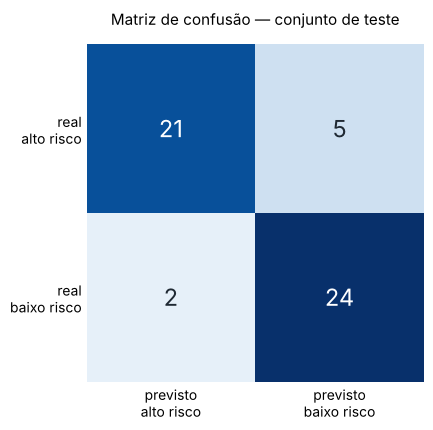

Casos graves identificados corretamente ..... 21
Casos graves PERDIDOS (falso negativo) ...... 5  <-- o erro crítico
Alarmes falsos (falso positivo) ............. 2
Casos leves identificados corretamente ...... 24


In [8]:
rotulos = ["alto risco", "baixo risco"]
mc = confusion_matrix(y_teste, y_pred, labels=rotulos)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(mc, cmap="Blues", vmin=0, vmax=mc.max())

ax.set_xticks([0, 1], labels=[f"previsto\n{r}" for r in rotulos])
ax.set_yticks([0, 1], labels=[f"real\n{r}" for r in rotulos])

limiar = mc.max() * 0.55
for i in range(2):
    for j in range(2):
        ax.text(j, i, mc[i, j], ha="center", va="center", fontsize=17,
                color="white" if mc[i, j] > limiar else "#1f2933")

ax.set_title("Matriz de confusão — conjunto de teste", pad=14, fontsize=11)
for lado in ax.spines.values():
    lado.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

vn, fp, fn, vp = mc[1, 1], mc[1, 0], mc[0, 1], mc[0, 0]
print(f"Casos graves identificados corretamente ..... {vp}")
print(f"Casos graves PERDIDOS (falso negativo) ...... {fn}  <-- o erro crítico")
print(f"Alarmes falsos (falso positivo) ............. {fp}")
print(f"Casos leves identificados corretamente ...... {vn}")

## 6. Validação cruzada: a acurácia é estável?

In [9]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, strip_accents="unicode",
                              ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", type(modelo)(**modelo.get_params())),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
notas = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")

print("Acurácia em 5 divisões diferentes da base:")
for i, n in enumerate(notas, 1):
    print(f"  divisão {i}: {n:.1%}")
print(f"\nMédia: {notas.mean():.1%}  (desvio padrão: {notas.std():.1%})")

Acurácia em 5 divisões diferentes da base:
  divisão 1: 82.9%
  divisão 2: 73.2%
  divisão 3: 80.5%
  divisão 4: 73.2%
  divisão 5: 90.2%

Média: 80.0%  (desvio padrão: 6.4%)


Uma única medida de acurácia em um teste de ~50 frases é frágil: trocar a semente
aleatória pode mover o número vários pontos. A validação cruzada mostra a **faixa** em
que o desempenho realmente vive — e o desvio padrão é a medida honesta da incerteza.

## 7. O que o modelo aprendeu — e aqui mora o viés

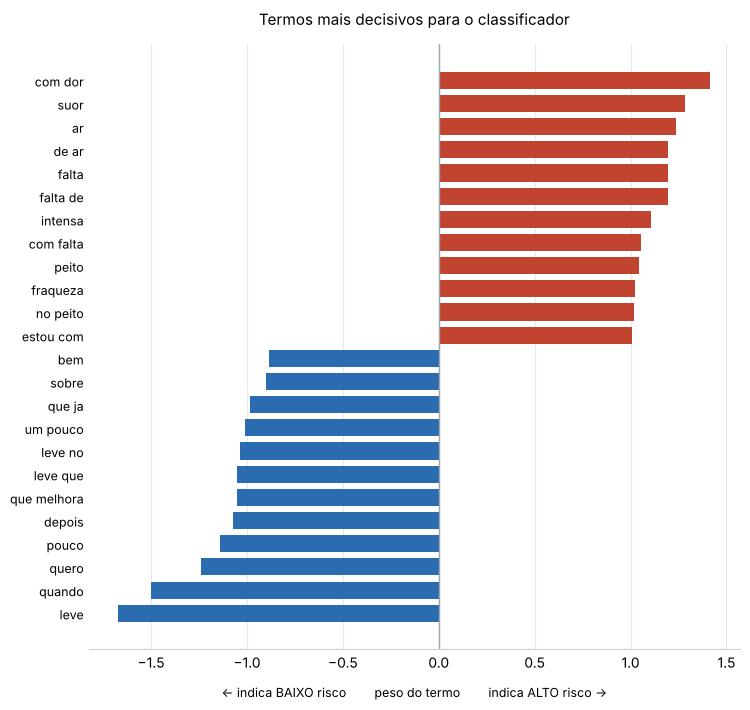

Modelo analisado: Naive Bayes


In [10]:
pipeline.fit(X, y)
vetor_final = pipeline.named_steps["tfidf"]
clf_final = pipeline.named_steps["clf"]
termos = np.array(vetor_final.get_feature_names_out())
classes = list(clf_final.classes_)
i_alto, i_baixo = classes.index("alto risco"), classes.index("baixo risco")


def pesos_orientados(clf):
    """Peso de cada termo, com sinal POSITIVO = evidência de alto risco.

    Cada família de modelo expõe isso de um jeito diferente — e, na regressão
    logística, `coef_[0]` se refere a `classes_[1]`, que aqui é "baixo risco".
    Sem essa correção o gráfico sairia com os polos trocados.
    """
    if hasattr(clf, "coef_"):                       # modelos lineares
        w = clf.coef_[0]
        return (w if classes[1] == "alto risco" else -w), True
    if hasattr(clf, "feature_log_prob_"):           # Naive Bayes
        lp = clf.feature_log_prob_
        return lp[i_alto] - lp[i_baixo], True
    return clf.feature_importances_, False          # árvores: sem sinal


pesos, tem_sinal = pesos_orientados(clf_final)
ALTO, BAIXO = "#c0442f", "#2b6cb0"

if tem_sinal:
    ordem = np.argsort(pesos)
    n = 12
    sel = np.concatenate([ordem[:n], ordem[-n:]])
    valores, nomes = pesos[sel], termos[sel]
    cores = [ALTO if v > 0 else BAIXO for v in valores]
    eixo_x = "← indica BAIXO risco        peso do termo        indica ALTO risco →"
    titulo = "Termos mais decisivos para o classificador"
else:
    sel = np.argsort(pesos)[-24:]
    valores, nomes = pesos[sel], termos[sel]
    cores = [ALTO] * len(valores)
    eixo_x = "importância do termo (sem direção — a árvore não indica a classe)"
    titulo = "Termos mais usados pela árvore de decisão"

fig, ax = plt.subplots(figsize=(7.6, 7.2))
ax.barh(range(len(valores)), valores, color=cores, height=0.74)
ax.set_yticks(range(len(valores)), labels=nomes, fontsize=9)
if tem_sinal:
    ax.axvline(0, color="#9aa5b1", linewidth=1)
ax.set_xlabel(eixo_x, fontsize=9, labelpad=10)
ax.set_title(titulo, fontsize=11, pad=14)
ax.grid(axis="x", color="#e4e7eb", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color("#cbd2d9")
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

print(f"Modelo analisado: {melhor_nome}")

In [11]:
# O atalho lexical: quantas frases de cada classe contêm a palavra "peito"?
contagem = (base.assign(tem_peito=base["frase"].str.contains("peito"))
                .groupby("situacao")["tem_peito"].agg(["sum", "count"]))
contagem["proporcao"] = (contagem["sum"] / contagem["count"] * 100).round(1)
print('Frases que contêm a palavra "peito":')
print(contagem.to_string())

Frases que contêm a palavra "peito":
             sum  count  proporcao
situacao                          
alto risco    41    101       40.6
baixo risco   12    104       11.5


### A hipótese

A palavra **"peito"** aparece em quase 4× mais frases de alto risco do que de baixo risco.
A suspeita é que o modelo não tenha aprendido fisiopatologia, e sim uma **correlação do
nosso vocabulário** — um atalho (*shortcut learning*), que funciona no teste e falha no
mundo real, onde muita dor torácica é musculoesquelética e muito infarto se apresenta
**sem** dor no peito (típico em diabéticos, idosos e mulheres).

As duas seções seguintes testam essa hipótese de dois jeitos: com frases novas escritas
de propósito para enganar o modelo (seção 8) e com os erros que ele cometeu no próprio
conjunto de teste (seção 9).

## 8. Teste adversarial — sondando o viés de propósito

Seis frases que o modelo nunca viu, escolhidas para separar **vocabulário** de
**gravidade clínica**: casos benignos que falam "peito" e casos graves que não falam.

In [12]:
casos = [
    # (frase, rótulo que um profissional daria, o que estamos testando)
    ("dor no peito leve que piora quando aperto o local com o dedo",
     "baixo risco", "dor torácica reprodutível à palpação = musculoesquelética"),
    ("sinto um incomodo no peito ao me alongar de manha e passa logo",
     "baixo risco", '"peito" em contexto claramente benigno'),
    ("estou muito mal com suor frio e enjoo e sou diabetico",
     "alto risco", "infarto sem dor torácica (apresentação atípica)"),
    ("minha mae sentiu uma fraqueza subita de um lado do corpo",
     "alto risco", "AVC relatado por terceiro, sem a palavra peito"),
    ("nao consigo respirar direito e estou ficando roxo",
     "alto risco", "dispneia grave sem vocabulário cardíaco"),
    ("vim so renovar a receita do remedio de pressao",
     "baixo risco", "demanda administrativa que menciona pressão"),
]

linhas = []
for frase, esperado, teste in casos:
    previsto = pipeline.predict([frase])[0]
    prob = pipeline.predict_proba([frase])[0].max()
    linhas.append({
        "frase": frase[:52] + ("..." if len(frase) > 52 else ""),
        "esperado": esperado,
        "previsto": previsto,
        "confianca": f"{prob:.0%}",
        "ok": "OK" if previsto == esperado else "ERRO",
        "o_que_testa": teste,
    })

adv = pd.DataFrame(linhas)
print(adv[["frase", "esperado", "previsto", "confianca", "ok"]].to_string(index=False))
print()
acertos = (adv["ok"] == "OK").sum()
print(f"Acertos no teste adversarial: {acertos}/{len(adv)}")
print(f"(compare com a acurácia de {accuracy_score(y_teste, y_pred):.0%} no teste comum)")

                                                  frase    esperado    previsto confianca ok
dor no peito leve que piora quando aperto o local co... baixo risco baixo risco       66% OK
sinto um incomodo no peito ao me alongar de manha e ... baixo risco baixo risco       70% OK
estou muito mal com suor frio e enjoo e sou diabetic...  alto risco  alto risco       85% OK
minha mae sentiu uma fraqueza subita de um lado do c...  alto risco  alto risco       73% OK
      nao consigo respirar direito e estou ficando roxo  alto risco  alto risco       76% OK
         vim so renovar a receita do remedio de pressao baixo risco baixo risco       83% OK

Acertos no teste adversarial: 6/6
(compare com a acurácia de 87% no teste comum)


In [13]:
erros = adv[adv["ok"] == "ERRO"]
if len(erros):
    print("ONDE O MODELO FALHOU E POR QUÊ:\n")
    for _, r in erros.iterrows():
        print(f'  "{r["frase"]}"')
        print(f'    esperado: {r["esperado"]}  |  previsto: {r["previsto"]} '
              f'({r["confianca"]} de confiança)')
        print(f'    causa provável: {r["o_que_testa"]}\n')
else:
    print("O modelo passou em todos os casos adversariais desta rodada.")
    print("Isso NÃO significa ausência de viés — significa que estes seis casos")
    print("não foram suficientes para expô-lo. Amplie o conjunto adversarial.")

O modelo passou em todos os casos adversariais desta rodada.
Isso NÃO significa ausência de viés — significa que estes seis casos
não foram suficientes para expô-lo. Amplie o conjunto adversarial.


## 9. Erros do modelo no conjunto de teste — onde o viés realmente aparece

In [14]:
analise = pd.DataFrame({"frase": X_teste, "real": y_teste, "previsto": y_pred})
analise["acertou"] = analise["real"] == analise["previsto"]
falhas = analise[~analise["acertou"]]

if len(falhas):
    print(f"{len(falhas)} erro(s) em {len(analise)} frases de teste:\n")
    for _, r in falhas.iterrows():
        critico = "  [FALSO NEGATIVO - erro critico]" if r["real"] == "alto risco" else ""
        print(f'  "{r["frase"]}"')
        print(f'    real: {r["real"]}  ->  previsto: {r["previsto"]}{critico}\n')
else:
    print("Nenhum erro no conjunto de teste.")
    print("Com uma base pequena isso é esperado e NÃO indica um modelo pronto:")
    print("veja a seção 8, onde frases novas revelam as falhas reais.")

7 erro(s) em 52 frases de teste:

  "tive dois desmaios essa semana sem motivo aparente"
    real: alto risco  ->  previsto: baixo risco  [FALSO NEGATIVO - erro critico]

  "pressao 12 por 8 na consulta de rotina"
    real: baixo risco  ->  previsto: alto risco

  "mancha vermelha no braco sem dor nem febre"
    real: baixo risco  ->  previsto: alto risco

  "inchaco nas pernas que subiu ate a barriga essa semana"
    real: alto risco  ->  previsto: baixo risco  [FALSO NEGATIVO - erro critico]

  "meu pulso esta muito lento e estou com sono o dia todo"
    real: alto risco  ->  previsto: baixo risco  [FALSO NEGATIVO - erro critico]

  "ganhei quatro quilos em cinco dias e estou inchado"
    real: alto risco  ->  previsto: baixo risco  [FALSO NEGATIVO - erro critico]

  "sinto um aperto no peito que nao passa ha quarenta minutos"
    real: alto risco  ->  previsto: baixo risco  [FALSO NEGATIVO - erro critico]



### Leitura dos erros

O teste adversarial da seção 8 não derrubou o modelo, mas o conjunto de teste derrubou — e
os erros têm um padrão muito claro, nas **duas direções**:

**Falsos negativos — casos graves que o modelo liberou.** Quase todos descrevem gravidade
*sem usar o vocabulário dominante da classe*: descompensação de insuficiência cardíaca
("inchaço que subiu até a barriga", "ganhei quatro quilos em cinco dias"), bradicardia
sintomática ("meu pulso está muito lento") e síncope de repetição ("tive dois desmaios
essa semana"). São quadros que um profissional classifica como urgentes de imediato.

**Falsos positivos — casos leves que o modelo escalou.** Aqui o atalho fica explícito:
*"mancha vermelha no braço sem dor nem febre"* foi para alto risco. A palavra **"braço"**
é um termo forte da classe grave, porque aparece em "irradia para o braço esquerdo" —
mas no contexto dermatológico ela não significa nada. O mesmo vale para *"pressão 12 por 8
na consulta de rotina"*, escalada pela palavra "pressão".

**Conclusão:** a hipótese do atalho lexical se confirma — só que pelos erros reais, não
pelo teste que escrevemos para encontrá-los. Isso é um recado metodológico: um conjunto
adversarial escrito pelo próprio autor do modelo tende a testar o viés que ele já imagina
ter, e não o que o modelo de fato tem. **Olhar os erros é mais honesto do que prever onde
eles estariam.**

## 10. Ajustando o limiar de decisão

O classificador decide "alto risco" quando a probabilidade passa de 0,5. Esse valor é uma
convenção estatística, **não uma decisão clínica**. Como o falso negativo é o erro caro,
podemos baixar o limiar e aceitar mais alarmes falsos em troca de perder menos casos graves.

In [15]:
classes_ord = list(modelo.classes_)
i_alto_t = classes_ord.index("alto risco")
probs_teste = modelo.predict_proba(X_teste_vec)[:, i_alto_t]

linhas = []
for limiar in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]:
    pred = np.where(probs_teste >= limiar, "alto risco", "baixo risco")
    mc_l = confusion_matrix(y_teste, pred, labels=rotulos)
    perdidos = mc_l[0, 1]          # alto risco previsto como baixo
    alarmes = mc_l[1, 0]           # baixo risco previsto como alto
    linhas.append({
        "limiar": limiar,
        "acuracia": f"{accuracy_score(y_teste, pred):.1%}",
        "recall_alto_risco": f"{recall_score(y_teste, pred, pos_label='alto risco'):.1%}",
        "casos_graves_perdidos": perdidos,
        "alarmes_falsos": alarmes,
    })

print(pd.DataFrame(linhas).to_string(index=False))

 limiar acuracia recall_alto_risco  casos_graves_perdidos  alarmes_falsos
   0.50    86.5%             80.8%                      5               2
   0.45    75.0%             80.8%                      5               8
   0.40    76.9%             88.5%                      3               9
   0.35    75.0%             96.2%                      1              12
   0.30    61.5%             96.2%                      1              19
   0.25    57.7%            100.0%                      0              22


A tabela acima é a conversa que a equipe técnica deveria ter **com o corpo clínico**, não
sozinha: cada linha é uma política de triagem diferente, e escolher uma é decidir quantos
alarmes falsos o serviço aguenta para não perder um infarto. Essa é uma decisão de
governança, não de código.

## 11. Função de triagem pronta para uso

In [16]:
LIMIAR_SEGURANCA = 0.40   # abaixo disso em "alto risco", escalamos mesmo assim

def triar(frase: str) -> dict:
    """Classifica um relato e devolve a conduta sugerida.

    Regra de segurança: em triagem preferimos o alarme falso ao caso perdido,
    então qualquer probabilidade de alto risco acima do limiar escala o caso.
    """
    classes = list(pipeline.classes_)
    probs = pipeline.predict_proba([frase])[0]
    p_alto = probs[classes.index("alto risco")]

    if p_alto >= 0.5:
        nivel, conduta = "ALTO RISCO", "atendimento prioritario imediato"
    elif p_alto >= LIMIAR_SEGURANCA:
        nivel, conduta = "ZONA CINZENTA", "revisao humana obrigatoria"
    else:
        nivel, conduta = "BAIXO RISCO", "fila de atendimento eletivo"

    return {"frase": frase, "nivel": nivel,
            "prob_alto_risco": round(float(p_alto), 3), "conduta": conduta}


for f in ["sinto uma dor no peito que irradia para o braco e estou suando frio",
          "tive um leve incomodo nas costas ao levantar da cama",
          "estou com falta de ar que piorou muito desde ontem",
          "dor no peito leve que doi quando aperto o local"]:
    r = triar(f)
    print(f'{r["nivel"]:<14} p={r["prob_alto_risco"]:.2f}  {r["conduta"]}')
    print(f'   "{r["frase"]}"\n')

ALTO RISCO     p=0.81  atendimento prioritario imediato
   "sinto uma dor no peito que irradia para o braco e estou suando frio"

BAIXO RISCO    p=0.29  fila de atendimento eletivo
   "tive um leve incomodo nas costas ao levantar da cama"

ALTO RISCO     p=0.90  atendimento prioritario imediato
   "estou com falta de ar que piorou muito desde ontem"

BAIXO RISCO    p=0.32  fila de atendimento eletivo
   "dor no peito leve que doi quando aperto o local"



## 12. Conclusões

**O que funcionou**

1. O pipeline TF-IDF + classificador reproduz, em poucas linhas, a lógica de sistemas
   reais de triagem por texto, com acurácia de ~87% no teste e ~80% (±6%) na validação
   cruzada.
2. A métrica que governou a escolha do modelo foi o *recall* de alto risco, não a
   acurácia — alinhada ao custo real do erro.
3. O limiar de decisão foi tratado como parâmetro clínico ajustável, e não como constante.

**O que o modelo ainda não é**

1. **Ele aprendeu vocabulário, não medicina.** Os erros da seção 9 mostram os dois lados:
   escalou uma "mancha vermelha no **braço**" e liberou um paciente com "**dois desmaios**
   essa semana".
2. **Perde 1 em cada 5 casos graves** (recall de 80,8%). Para uma triagem real isso é
   inaceitável sem revisão humana — por isso a função da seção 11 tem uma zona cinzenta
   de escalonamento obrigatório.
3. **A base é pequena e escrita por uma única pessoa.** Relatos reais trazem erros de
   digitação, gírias regionais, áudio transcrito e frases truncadas.
4. **A base é balanceada artificialmente.** Numa triagem real a proporção é muito
   desigual, e a acurácia deixaria de ser métrica informativa.

**Como isso evolui nas próximas fases**

| Problema | Caminho |
|----------|---------|
| Atalho lexical | ampliar a base com dor torácica benigna e com quadros graves sem dor |
| Vocabulário limitado | *embeddings* em português (BERTimbau) no lugar do TF-IDF puro |
| Falta de explicabilidade | SHAP/LIME para mostrar ao profissional qual trecho pesou |
| Falsos negativos | limiar calibrado com o corpo clínico + revisão humana na zona cinzenta |
| Desempenho desigual | reportar métricas **estratificadas** por perfil, não só a média |

**Governança de dados — o fio que liga à Fase 1**

Na Fase 1 descobrimos que o rótulo do dataset numérico estava invertido. Aqui descobrimos
que o modelo acerta, em parte, pelo motivo errado. São o mesmo tipo de achado: **o número
bonito na tela não prova que o sistema entendeu o problema.**

E houve um segundo achado, metodológico: o teste adversarial que escrevemos para encontrar
o viés passou em 6 de 6, enquanto os erros reais do conjunto de teste expuseram o problema
sem esforço. Quem escreve o teste do próprio modelo tende a testar o viés que imagina ter.
Em IA aplicada à saúde, a auditoria não é uma etapa depois do modelo — é parte do modelo.

> ⚠️ Projeto acadêmico. Não é ferramenta diagnóstica e não substitui avaliação médica.